In [ ]:
import multiprocessing
import os

import importlib
import numpy as np
import pandas as pd
import cli_pred as cp
importlib.reload(cp)
import tifffile as tiff
import glob
from multiprocessing import Process


class PQCalculator:
    def __init__(self, ids):
        self.ids = ids
        self.length = len(ids)
        self.labels = list(range(0, 256 ** 2, 1))

    """
    def calc_cod(self, cl):
        res = []
        lab = []

        CD = os.path.dirname(os.path.abspath("temp.ipynb"))
        patch_names = pd.read_csv(os.path.join(os.path.dirname(CD), "CRC-HnE-Segmentation-Training", "histology_segmentation_training", "data", "patches", "patch_info.csv"))

        for val in self.ids:
            image, label = cp.read_data_to_predict(os.path.join(os.path.dirname(CD), "CRC-HnE-Segmentation-Training", "histology_segmentation_training", "data", "OME-TIFFs", patch_names.iloc[val, 0] + ".ome.tif"))
            model = cp.get_pytorch_model("models/U_NET.ckpt", False)
            result = cp.predict(image, model)
            result = np.argmax(result.detach().numpy(), axis=1)
            label = label[16:240, 16:240]
            result = result[0, 16:240, 16:240]
            if cl > 0:
                mask = result == cl
                result = mask * result
                mask = label == cl
                label = mask * label
            print(len(np.unique(self.nb_4_tiles(result))))
            res.append(len(np.unique(self.nb_4_tiles(result))))
            lab.append(len(np.unique(self.nb_4_tiles(label))))
        return res, lab
    """


    def calc_sem_iou(self, gt, mask, num_classes=None, ignore_index=None):
        ious = {}
        dices = {}
        gt = np.array(gt)
        mask = np.array(mask)

        classes = np.unique(gt)
        print(f"Unique classes in GT: {classes}")

        if ignore_index is not None:
            classes = classes[classes != ignore_index]

        for c in classes:
            gt_c = (gt == c)
            pred_c = (mask == c)

            intersection = np.logical_and(gt_c, pred_c).sum()
            union = np.logical_or(gt_c, pred_c).sum()

            iou = intersection / union if union > 0 else 0
            dice = (2 * intersection) / (gt_c.sum() + pred_c.sum()) if (gt_c.sum() + pred_c.sum()) > 0 else 0

            ious[c] = iou
            dices[c] = dice

        if len(ious) > 0:
            mean_iou = np.mean(list(ious.values()))
        else:
            mean_iou = 0.0

        if len(dices) > 0:
            mean_dice = np.mean(list(dices.values()))
        else:            
            mean_dice = 0.0

        binary_gt = (gt != 0)
        binary_mask = (mask != 0)
        intersection = np.logical_and(binary_gt, binary_mask).sum()
        union = np.logical_or(binary_gt, binary_mask).sum()

        binary_iou = intersection / union if union > 0 else 0
        binary_dice = (2 * intersection) / (binary_gt.sum() + binary_mask.sum()) if (binary_gt.sum() + binary_mask.sum()) > 0 else 0

        print(f"Class IoUs: {ious.items()}, Mean IoU: {mean_iou}")
        print(f"Class Dices: {dices.items()}, Mean Dice: {mean_dice}")
        print(f"Binary IoU: {binary_iou}, Binary Dice: {binary_dice}")

        return ious, mean_iou, binary_iou, dices, mean_dice, binary_dice



    def calc_PQ(self, ids):
        with multiprocessing.Manager() as manager:
            qL = manager.list()
            mL_ins = manager.list()
            mL_seg = []

            CD = os.path.dirname(os.path.abspath("temp.ipynb"))
            patch_names = pd.read_csv(os.path.join(os.path.dirname(CD), "CRC-HnE-Segmentation-Training", "histology_segmentation_training", "data", "patches", "patch_info.csv"))

            #model = cp.get_pytorch_model("../CRC-HnE-Segmentation-Training/mlruns/unet_fromC32_Aug_backgound0_5/best_Unet_lr-0.003_wd-1e-05_dropout-0.015_epoch-250_batchS-64-v3.ckpt", False, "U-Net")
            #model = cp.get_pytorch_model("U_NET.ckpt", False, "U-Net")
            #model = cp.get_pytorch_model("../CRC-HnE-Segmentation-Training/mlruns/unext_fromC32_Aug_backgroud1/best_UneXt_lr-0.003_wd-1e-05_dropout-0.015_epoch-250_batchS-32.ckpt", False, "U-NeXt")
            model = cp.get_pytorch_model("../CRC-HnE-Segmentation-Training/mlruns/swinunetr_fromC32_Aug_background0_5/best_swinUNETR_lr-0.0005_wd-1e-05_dropout-0.01_epoch-250_batchS-16-v1.ckpt", False, "swin-UNETR")

        

            for idx in range(len(ids)):
                mL_seg = self.process_pipeline(os.path.join(os.path.dirname(CD), "CRC-HnE-Segmentation-Training", "histology_segmentation_training", "data", "OME-TIFFs", patch_names.iloc[ids[idx], 0] + ".ome.tif"), patch_names.iloc[ids[idx], 0], 0, qL, mL_ins, mL_seg, model)
                #p1 = Process(target=self.process_pipeline, args=(os.path.join(os.path.dirname(CD), "CRC-HnE-Segmentation-Training", "histology_segmentation_training", "data", "OME-TIFFs", patch_names.iloc[val, 0] + ".ome.tif"), self.ids[val], cl, qL, mL_ins, mL_seg, model))
                #p2 = Process(target=self.process_pipeline, args=(os.path.join(os.path.dirname(CD), "CRC-HnE-Segmentation-Training", "histology_segmentation_training", "data", "OME-TIFFs", patch_names.iloc[val + 1, 0] + ".ome.tif"), self.ids[val + 1], cl, qL, mL_ins, mL_seg, model))
                #p3 = Process(target=self.process_pipeline, args=(os.path.join(os.path.dirname(CD), "CRC-HnE-Segmentation-Training", "histology_segmentation_training", "data", "OME-TIFFs", patch_names.iloc[val + 2, 0] + ".ome.tif"), self.ids[val + 2], cl, qL, mL_ins, mL_seg))
                #p4 = Process(target=self.process_pipeline, args=(os.path.join(os.path.dirname(CD), "CRC-HnE-Segmentation-Training", "histology_segmentation_training", "data", "OME-TIFFs", patch_names.iloc[val + 3, 0] + ".ome.tif"), self.ids[val + 3], cl, qL, mL_ins, mL_seg))
                #p1.start()
                #p2.start()
                #p3.start()
                #p4.start()
                #p1.join()
                #p2.join()
                #p3.join()
                #p4.join()
            #qual = list(qL)
            #mets = list(mL_ins)
            #segs = list(mL_seg)
        #self.qs = np.array(qual)
        #self.mets = np.array(mets)
        self.segs = np.array(mL_seg)
        np.save("metrics_segs_c", self.segs)

    def load_image(self, path, mask: bool):
        data = tiff.imread(path)
        label = data[3, :, :]
        image = data[:3, :, :]
        if mask:
            return label
        return image, label

    def read_data_to_predict(self, path):
        data = tiff.imread(path)
        label = data[3, :, :]
        image = data[:3, :, :]
        return image, label

    def process_pipeline(self, iD, val, cl, qL, ml_ins, ml_seg, model):
        image, label = self.read_data_to_predict(iD)
        #model = cp.get_pytorch_model("U_NET.ckpt", False, "U-Net")
        result = cp.predict(image, model)
        result = np.argmax(result.detach().numpy(), axis=1)
        np.save("mask", result)
        #result = result.detach().numpy()[0]
        #pred = np.argmax(result, axis=0)
        #bg = result[0]
        #nuclei_max = np.max(result[1:], axis=0)
        #margin = 0.05
        #uncertain = (pred != 0) & (bg > (nuclei_max - margin))
        #pred[uncertain] = 0
        #result = pred

        """
        if cl > 0:
            mask = result == cl
            result = mask * result
            mask = label == cl
            label = mask * label
        print("Currently working on {}".format(val))
        """

        #ins_metrics = self.intersection_two_instances(self.nb_4_tiles(label), self.nb_4_tiles(result))
        sem_metrics = self.calc_sem_iou(label, result)

        #try:
        #    sq = ins_metrics[2] / ins_metrics[0]
        #    rq = ins_metrics[0] / (ins_metrics[0] + 0.5 * ins_metrics[1] + 0.5 * ins_metrics[3])
        #except:
        #    sq = 0
        #    rq = 0

        #ml_ins.append(ins_metrics)
        ml_seg.append(sem_metrics)
        return ml_seg
        #qL.append([sq, rq])

    def union(self, x, y):
        x = int(x)
        y = int(y)
        self.labels[self.find(x)] = self.find(y)

    def find(self, x):
        x = int(x)
        y = x
        while self.labels[y] != y:
            y = self.labels[y]
        while self.labels[x] != x:
            z = self.labels[x]
            self.labels[x] = y
            x = z
        return y

    def nb_4_tiles(self, original_arr):
        if len(original_arr.shape) == 2:
            n_columns = original_arr.shape[-1]
            n_rows = original_arr.shape[-1]
            largest_label = 1
            label = np.zeros([n_columns, n_rows])
            for x in range(0, n_columns):
                for y in range(0, n_rows):
                    if original_arr[x, y] != 0:
                        left = label[x - 1, y]
                        above = label[x, y - 1]
                        if (left == 0) and (above == 0):
                            largest_label = largest_label + 1
                            label[x, y] = largest_label
                        elif (left != 0) and (above == 0):
                            label[x, y] = self.find(left)
                        elif (left == 0) and (above != 0):
                            label[x, y] = self.find(above)
                        else:
                            self.union(left, above)
                            label[x, y] = self.find(left)
            return label
        else:
            labels = np.empty(original_arr.shape)
            for val, i in enumerate(original_arr):
                labels[val] = self.nb_4_tiles(i)
            return labels

    def intersection_two_instances(self, ground_truth, mask):
        tp = 0
        fp = 0
        tp_ious = 0
        
        gt_instances = list(np.unique(ground_truth))[1:]
        pred_instances = list(np.unique(mask))[1:]

        matched_preds = set()  
        fns = set(gt_instances)  

        for gt_val in gt_instances:
            gt_mask = ground_truth == gt_val
            best_iou = 0
            best_pred = None

            # find the predicted instance with highest IoU
            for pred_val in pred_instances:
                if pred_val in matched_preds:
                    continue  # already matched predictions

                pred_mask = mask == pred_val
                intersection = np.logical_and(gt_mask, pred_mask).sum()
                union = np.logical_or(gt_mask, pred_mask).sum()
                iou = intersection / union if union > 0 else 0

                if iou > best_iou:
                    best_iou = iou
                    best_pred = pred_val

            # evaluate the best match
            if best_iou >= 0.5:  
                tp += 1
                tp_ious += best_iou
                matched_preds.add(best_pred)
                fns.discard(gt_val)  # remove matched ground truth val
            else:
                # no good match
                continue

        # unmatched predictions as FP
        fp = len(set(pred_instances) - matched_preds)
        return tp, fp, tp_ious, len(fns)



if __name__ == '__main__':
    """
    test_id = [166, 2197, 1519, 1654, 2986, 4891, 3021, 1536, 653, 279, 1405, 605, 4336, 3095, 1209, 350, 19, 4485, 247,
               4240, 1589, 2481, 2759, 3836, 2629, 1338, 3935, 3932, 356, 3429, 3277, 4502, 3624, 1652, 463, 2311, 4906,
               4418, 4679, 677, 1557, 1503, 2462, 535, 755, 254, 2307, 309, 4133, 3250, 177, 198, 4946, 4923, 413, 4388,
               3339, 4005, 1592, 1945, 1024, 1051, 2110, 1034, 3880, 3599, 4184, 4596, 2510, 3595, 1044, 1164, 1569,
               4611, 3800, 596, 1526, 501, 4209, 1210, 2194, 4023, 1534, 4063, 149, 387, 4214, 615, 549, 3153, 4258,
               4571, 765, 1595, 3018, 507, 2576, 3754, 4511, 4130, 228, 4873, 3892, 1554, 4512, 1187, 4567, 3185, 2395,
               1504, 2984, 1371, 4445, 4814, 486, 4882, 2297, 2053, 3906, 2702, 1566, 2527, 4003, 436, 4840, 2865, 2575,
               511, 3994, 3834, 157, 805, 4236, 490, 3720, 1803, 3570, 4411, 2910, 2732, 679, 4947, 2521, 4379, 4352,
               594, 4774, 4903, 1046, 2902, 4837, 4575, 4256, 188, 3845, 945, 862, 4557, 2847, 4597, 4036, 787, 93,
               1322, 3138, 1095, 305, 643, 4561, 887, 1255, 3370, 2534, 4450, 4062, 274, 1480, 3752, 2881, 2252, 2177,
               2346, 1618, 214, 3411, 2211, 3706, 565, 4956, 1212, 433, 1590, 4576, 1378, 3313, 2754, 2406, 1215, 208,
               1937, 4304, 371, 1891, 2144, 2004, 1032, 4398, 841, 211, 633, 122, 3887, 1808, 4190, 1600, 611, 1407,
               298, 705, 3768, 620, 3779, 1101, 1451, 1157, 3247, 3864, 445, 2100, 2767, 2331, 627, 1497, 1609, 1815,
               3883, 4665, 1434, 2220, 731, 3221, 3328, 3188, 1820, 2416, 1736, 3084, 1513, 111, 152, 4638, 4783, 4461,
               1412, 3983, 670, 3567, 4595, 494, 4654, 2995, 2215, 3832, 1543, 3428, 4157, 230, 2101, 3699, 4422, 3997,
               937, 461, 1437, 802, 527, 1351, 1479, 438, 1221, 73, 3733, 576, 465, 354, 248, 2464, 4257, 888, 450,
               2907, 144, 330, 1258, 1650, 517, 4098, 3543, 415, 561, 2794, 2921, 1469, 1113, 2990, 4670, 4542, 3494,
               1545, 3001, 915, 183, 1260, 2648, 3580, 3784, 3291, 790, 106, 2063, 4895, 4293, 4883, 497, 1818, 1084,
               3091, 2699, 4351, 256, 2638, 135, 1739, 2426, 3112, 191, 2748, 472, 506, 4080, 1666, 422, 1238, 1075,
               3896, 1231, 4085, 3227, 1323, 3634, 4217, 2615, 964, 2309, 457, 69, 828, 2369, 3203, 1907, 4976, 4375,
               680, 2445, 95, 3588, 4197, 2432, 1878, 1052, 2233, 2857, 2879, 1146, 1477, 2404, 952, 2083, 4842, 1362,
               3214, 2594, 2389, 332, 2059, 175, 1204, 879, 1242, 2672, 3919, 2592, 2103, 4508, 45, 3601, 3365, 353,
               4483, 2647, 1174, 4393, 3179, 4830, 70, 2337, 4354, 996, 3825, 1756, 3305, 794, 3026, 1919, 2471, 2303,
               1832, 4687, 2900, 1912, 4396, 1729, 911, 1281, 2765, 978, 4074, 711, 3757, 3539, 1144, 1932, 4409, 3270,
               3473, 831, 1718, 4490, 1293, 4683, 1620, 2409, 1786, 1483, 1482, 4634, 1397, 2275, 4943, 586, 4693, 4122,
               3749, 734, 1578, 3610, 4104, 859, 4608, 1588, 2052, 3080, 3703, 1391, 3349, 1615, 681, 252, 1117, 1426,
               4909, 4457, 1029, 3694, 742, 1773, 2287, 3050, 644, 4235, 1010, 179, 4326, 2915, 1957, 1964, 3742, 2837,
               1747, 2142, 360, 4942, 553, 2656, 4920, 2492, 2339, 3622, 3782, 4385, 4417, 1807, 733, 468, 2991, 2588,
               3905, 801, 1108, 3366, 170, 3801, 810, 1272, 4666, 518, 534, 3238, 725, 3482, 2088, 1752, 3044, 912,
               4439, 3591, 2804, 881, 3380, 2741, 3778, 3604, 4898, 4586, 4940, 2581, 259, 2498, 812, 2547, 293, 2812,
               3666, 4311, 2977, 2133, 1444, 564, 1813, 690, 4835, 1538, 2569, 4172, 2925, 4570, 2858, 2450, 2473, 4572,
               3447, 3811, 1873, 2304, 4335, 283, 2093, 1954, 4162, 4444, 2683, 4849, 530, 2119, 2728, 3526, 2932, 3550,
               2825, 192, 1417, 1175, 2655, 4710, 2072, 4625, 47, 2602, 2770, 4633, 2600, 2627, 1782, 1149, 4646, 1550,
               893, 1721, 4024, 278, 2372, 4753, 4479, 907, 3691, 2437, 2078, 691, 3586, 718, 2238, 3639, 3437, 2520,
               2456, 3659, 2603, 3554, 4701, 4230, 4420, 2284, 4359, 3646, 2111, 1539, 1564, 3268, 1870, 14, 4901, 4462,
               4205, 3770, 328, 3484, 625, 3934, 648, 1295, 1583, 3682, 3265, 544, 4044, 2153, 1128, 1041, 4763, 505,
               1769, 1616, 2892, 1886, 1074, 1738, 270, 4467, 3128, 798, 2698, 3263, 3043, 4119, 2092, 3886, 1532, 977,
               4281, 4017, 3353, 1614, 308, 1675, 2845, 4222, 4655, 3264, 1335, 896, 4046, 4255, 3988, 1361, 2317, 2118,
               4922, 1360, 3231, 598, 2277, 2519, 1433, 3331, 4207, 4711, 3984, 227, 184, 1849, 2771, 1751, 3625, 4629,
               1610, 4221, 3244, 2874, 1744, 1436, 4793, 3759, 4246, 3638, 1840, 1833, 3002, 68, 1746, 1189, 33, 3198,
               3918, 4515, 2518, 4977, 1438, 2042, 1926, 2002, 624, 3338, 2373, 378, 3296, 1961, 2587, 376, 708, 3740,
               4049, 4114, 287, 3269, 4544, 1413, 4347, 2402]
    """
    
    
    test_id = [605]
    
    pqc = PQCalculator(test_id)

    #for i in range(1, 7):
    #    res, lab = pqc.calc_cod(i)
    #    np.save("res_{}".format(i), np.array(res))
    #    np.save("lab_{}".format(i), np.array(lab))
    pqc.calc_PQ(test_id)
    #np.save("qualities_c_{}".format(i), pqc.qs)
    #np.save("metrics_ins_c_{}".format(i), pqc.mets)
    #np.save("metrics_segs_c_", pqc.segs)



Swin-UNETR model loaded from ../CRC-HnE-Segmentation-Training/mlruns/swinunetr_fromC32_Aug_background0_5/best_swinUNETR_lr-0.0005_wd-1e-05_dropout-0.01_epoch-250_batchS-16-v1.ckpt
Unique classes in GT: [0. 2. 3. 4. 5. 6.]
Class IoUs: dict_items([(0.0, 0.9331322521097046), (2.0, 0.0), (3.0, 0.2558139534883721), (4.0, 0.1480891719745223), (5.0, 0.2505694760820046), (6.0, 0.5205341395817586)]), Mean IoU: 0.3513564988727271
Class Dices: dict_items([(0.0, 0.9654096361915643), (2.0, 0.0), (3.0, 0.4074074074074074), (4.0, 0.2579750346740638), (5.0, 0.4007285974499089), (6.0, 0.6846727423363712)]), Mean Dice: 0.45269890300988597
Binary IoU: 0.5452303553413295, Binary Dice: 0.7056945955749002
Unique classes in GT: [0. 2. 6.]
Class IoUs: dict_items([(0.0, 0.7831277934116868), (2.0, 0.6178837884523504), (6.0, 0.3888888888888889)]), Mean IoU: 0.5966334902509753
Class Dices: dict_items([(0.0, 0.8783753988975921), (2.0, 0.7638172690306899), (6.0, 0.56)]), Mean Dice: 0.7340642226427607
Binary IoU: 0.

In [74]:
metrics = np.load("metrics_segs_unet_new.npy", allow_pickle=True)
#print((np.array(metrics)[:,1]).mean())
#print(len(metrics[0][0].keys()))

for idx, img in enumerate(metrics):
    if len(img[0].keys()) == 7:
        print(f"Image {test_id[idx]} has {len(img[0].keys())} classes with IoU metrics. Classes: {img[0].keys()}")

Image 605 has 7 classes with IoU metrics. Classes: dict_keys([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
Image 4418 has 7 classes with IoU metrics. Classes: dict_keys([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
Image 1503 has 7 classes with IoU metrics. Classes: dict_keys([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
Image 413 has 7 classes with IoU metrics. Classes: dict_keys([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
Image 4005 has 7 classes with IoU metrics. Classes: dict_keys([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
Image 3595 has 7 classes with IoU metrics. Classes: dict_keys([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
Image 4063 has 7 classes with IoU metrics. Classes: dict_keys([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
Image 387 has 7 classes with IoU metrics. Classes: dict_keys([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
Image 4571 has 7 classes with IoU metrics. Classes: dict_keys([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
Image 3185 has 7 classes with IoU metrics. Classes: dict_keys([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
Image 2395 ha

In [22]:
def print_class_metrics(file_path):

    metrics = np.load(file_path, allow_pickle=True)

    cls_0, cls_1, cls_2, cls_3, cls_4, cls_5, cls_6, cls_mean = [], [], [], [], [], [], [], []
    binary_iou_list = []
    binary_dice_list = []
    
    for cls_dict, mean_iou, binary_iou, dices, mean_dice, binary_dice in metrics: 
        binary_iou_list.append(binary_iou)
        binary_dice_list.append(binary_dice)
        for cls in range(0, 7):
            if cls in cls_dict:
                if cls == 0:
                    cls_0.append(cls_dict[cls])
                elif cls == 1:
                    cls_1.append(cls_dict[cls])
                elif cls == 2:
                    cls_2.append(cls_dict[cls])
                elif cls == 3:
                    cls_3.append(cls_dict[cls])
                elif cls == 4:
                    cls_4.append(cls_dict[cls])
                elif cls == 5:
                    cls_5.append(cls_dict[cls])
                elif cls == 6:
                    cls_6.append(cls_dict[cls])
        cls_mean.append(mean_iou)

    print(f"Mean IoU for class 0: {np.mean(cls_0)}, SD: {np.std(cls_0)}")
    print(f"Mean IoU for class 1: {np.mean(cls_1)}, SD: {np.std(cls_1)}")
    print(f"Mean IoU for class 2: {np.mean(cls_2)}, SD: {np.std(cls_2)}")
    print(f"Mean IoU for class 3: {np.mean(cls_3)}, SD: {np.std(cls_3)}")
    print(f"Mean IoU for class 4: {np.mean(cls_4)}, SD: {np.std(cls_4)}")
    print(f"Mean IoU for class 5: {np.mean(cls_5)}, SD: {np.std(cls_5)}")
    print(f"Mean IoU for class 6: {np.mean(cls_6)}, SD: {np.std(cls_6)}")
    print(f"Mean IoU for all classes: {np.mean(cls_mean)}, SD: {np.std(cls_mean)}")
    print(f"Mean Binary IoU: {np.mean(binary_iou_list)}, SD: {np.std(binary_iou_list)}")
    print(f"Mean Binary Dice: {np.mean(binary_dice_list)}, SD: {np.std(binary_dice_list)}")

In [23]:
# unet old
print_class_metrics("metrics_segs_unet_old.npy")

Mean IoU for class 0: 0.9239657534656102, SD: 0.041874038255130044
Mean IoU for class 1: 0.049056643246003374, SD: 0.0584447754369986
Mean IoU for class 2: 0.5486145202874226, SD: 0.14307134666021126
Mean IoU for class 3: 0.4108302803316252, SD: 0.15618108018557617
Mean IoU for class 4: 0.19127702486647338, SD: 0.1385531940788882
Mean IoU for class 5: 0.21416774732917987, SD: 0.16232302419945138
Mean IoU for class 6: 0.35169907269104744, SD: 0.14916611184397552
Mean IoU for all classes: 0.49711796863016616, SD: 0.12550619356854661
Mean Binary IoU: 0.6414373202219485, SD: 0.13252362496478462
Mean Binary Dice: 0.7700873029327057, SD: 0.1443805480292718


In [25]:
# unet new
print_class_metrics("metrics_segs_unet_new.npy")

Mean IoU for class 0: 0.9253941757033346, SD: 0.043244405366597224
Mean IoU for class 1: 0.19714030186951423, SD: 0.20093635132047433
Mean IoU for class 2: 0.6644175098019063, SD: 0.09898168162766605
Mean IoU for class 3: 0.5199463382036668, SD: 0.17032584694400466
Mean IoU for class 4: 0.2654196041681441, SD: 0.20945079276336134
Mean IoU for class 5: 0.3399367409166485, SD: 0.25770627190049394
Mean IoU for class 6: 0.503862831931508, SD: 0.15643725656236065
Mean IoU for all classes: 0.5868874487278385, SD: 0.12029246766380887
Mean Binary IoU: 0.669569212906769, SD: 0.1360764485127506
Mean Binary Dice: 0.7902435798054386, SD: 0.1474699649766888


In [80]:
# unext
print_class_metrics("metrics_segs_unext.npy")

Mean IoU for class 0: 0.9274622191655276, SD: 0.04093811902215457
Mean IoU for class 1: 0.19400817265624412, SD: 0.242892580878639
Mean IoU for class 2: 0.6502029070783057, SD: 0.11286323532898758
Mean IoU for class 3: 0.5183438626280235, SD: 0.19052528971797075
Mean IoU for class 4: 0.28505021789808116, SD: 0.21598334140003408
Mean IoU for class 5: 0.3511962944646555, SD: 0.27505446020647134
Mean IoU for class 6: 0.4710589461787275, SD: 0.16316045332740808
Mean IoU for all classes: 0.5784619318625931, SD: 0.123977088831725
Mean Binary IoU: 0.6447044893028299, SD: 0.14149262821044875
Mean Binary Dice: 0.7709839059533793, SD: 0.15353733005907788


In [82]:
# swin-unetr
print_class_metrics("metrics_segs_swinunetr.npy")

Mean IoU for class 0: 0.8924560393941422, SD: 0.05854903806431177
Mean IoU for class 1: 0.05191559693504269, SD: 0.10618210232578748
Mean IoU for class 2: 0.5731925951215526, SD: 0.09936883343476838
Mean IoU for class 3: 0.3813583169748832, SD: 0.1526784350608195
Mean IoU for class 4: 0.15409549780051224, SD: 0.1549169431426545
Mean IoU for class 5: 0.19502295076729015, SD: 0.19465189173128603
Mean IoU for class 6: 0.34723243030805817, SD: 0.1336365838613942
Mean IoU for all classes: 0.48272444984984686, SD: 0.12850539901955427
Mean Binary IoU: 0.5623906759696808, SD: 0.12727485845546802
Mean Binary Dice: 0.7084965876435286, SD: 0.14234829237168423


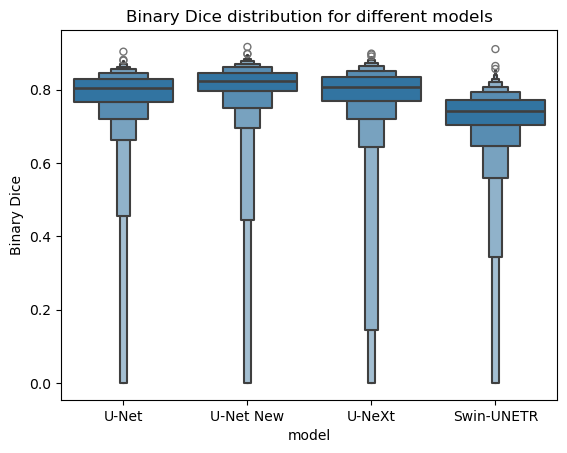

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metrics_unet_old = np.load("metrics_segs_unet_old.npy", allow_pickle=True)
metrics_unet_new = np.load("metrics_segs_unet_new.npy", allow_pickle=True)
metrics_unext = np.load("metrics_segs_unext.npy", allow_pickle=True)
metrics_swinunetr = np.load("metrics_segs_swinunetr.npy", allow_pickle=True)

df_binary_dice = pd.DataFrame({
    "U-Net": [metric[5] for metric in metrics_unet_old],
    "U-Net New": [metric[5] for metric in metrics_unet_new],
    "U-NeXt": [metric[5] for metric in metrics_unext],
    "Swin-UNETR": [metric[5] for metric in metrics_swinunetr]
})

df_binary_dice = df_binary_dice.melt(var_name="model", value_name="Binary Dice")

sns.boxenplot(x="model", y="Binary Dice", data=df_binary_dice, showfliers=True, linewidth=1.5, 
                k_depth='trustworthy')

plt.title("Binary Dice distribution for different models")
plt.show()

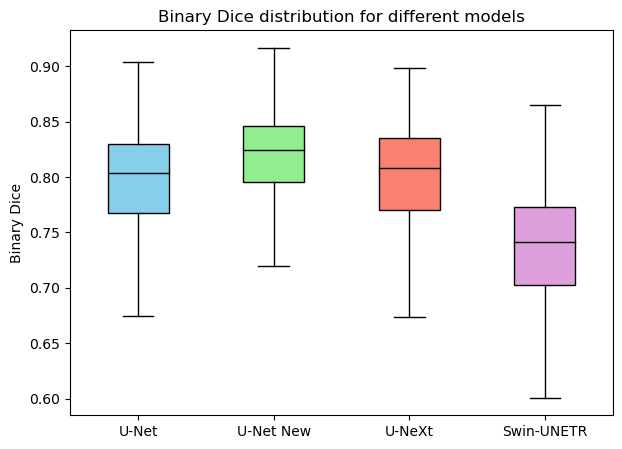

In [2]:
metrics_unet_old = np.load("metrics_segs_unet_old.npy", allow_pickle=True)
metrics_unet_new = np.load("metrics_segs_unet_new.npy", allow_pickle=True)
metrics_unext = np.load("metrics_segs_unext.npy", allow_pickle=True)
metrics_swinunetr = np.load("metrics_segs_swinunetr.npy", allow_pickle=True)

data = [
    metrics_unet_old[:, 5],
    metrics_unet_new[:, 5],
    metrics_unext[:, 5],
    metrics_swinunetr[:, 5]
]

labels = ["U-Net", "U-Net New", "U-NeXt", "Swin-UNETR"]
colors = ["skyblue", "lightgreen", "salmon", "plum"]

plt.figure(figsize=(7,5))

box =plt.boxplot(
    data,
    labels=labels,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1)
)

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

plt.ylabel("Binary Dice")
plt.title("Binary Dice distribution for different models")

plt.show()

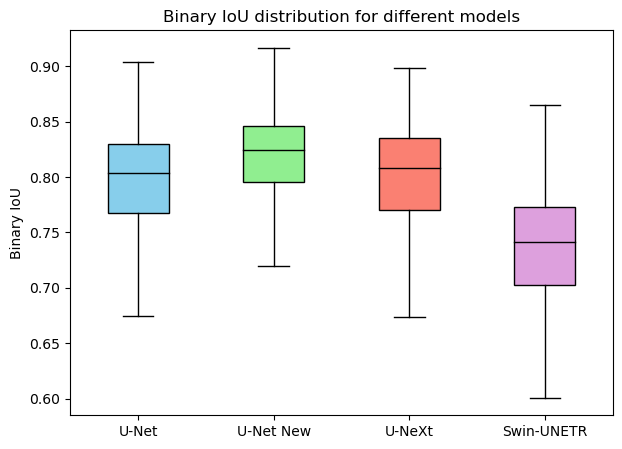

In [3]:
metrics_unet_old = np.load("metrics_segs_unet_old.npy", allow_pickle=True)
metrics_unet_new = np.load("metrics_segs_unet_new.npy", allow_pickle=True)
metrics_unext = np.load("metrics_segs_unext.npy", allow_pickle=True)
metrics_swinunetr = np.load("metrics_segs_swinunetr.npy", allow_pickle=True)

data = [
    metrics_unet_old[:, 5],
    metrics_unet_new[:, 5],
    metrics_unext[:, 5],
    metrics_swinunetr[:, 5]
]

labels = ["U-Net", "U-Net New", "U-NeXt", "Swin-UNETR"]
colors = ["skyblue", "lightgreen", "salmon", "plum"]

plt.figure(figsize=(7,5))

box =plt.boxplot(
    data,
    labels=labels,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1)
)

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

plt.ylabel("Binary IoU")
plt.title("Binary IoU distribution for different models")

plt.show()

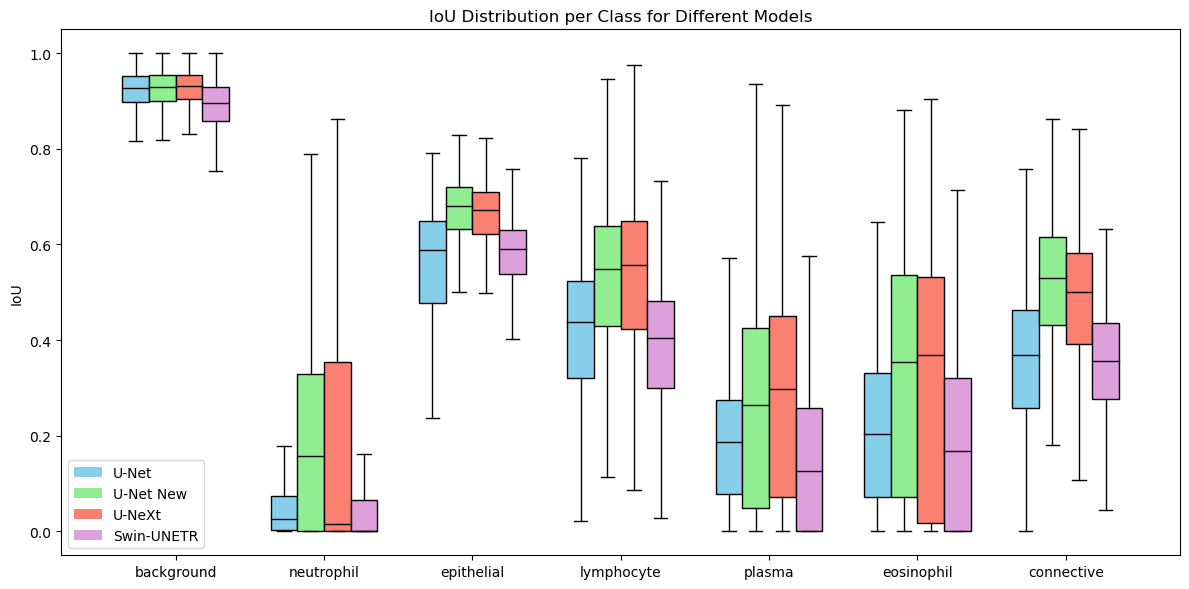

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import defaultdict

n_classes = 7

def collect_class_ious(metrics):
    class_ious = defaultdict(list)

    for metric in metrics:
        iou_dict = metric[0]  

        for cls, iou in iou_dict.items():
            class_ious[cls].append(iou)

    return [class_ious[i] for i in range(n_classes)]

data_unet_old = collect_class_ious(metrics_unet_old)
data_unet_new = collect_class_ious(metrics_unet_new)
data_unext = collect_class_ious(metrics_unext)
data_swin = collect_class_ious(metrics_swinunetr)

model_data = [data_unet_old, data_unet_new, data_unext, data_swin]
model_names = ["U-Net", "U-Net New", "U-NeXt", "Swin-UNETR"]
colors = ["skyblue", "lightgreen", "salmon", "plum"]

n_classes = 7
n_models = 4

positions = np.arange(n_classes)
box_width = 0.18

plt.figure(figsize=(12,6))

for i, (model, color) in enumerate(zip(model_data, colors)):

    pos = positions + (i - 1.5) * box_width

    box = plt.boxplot(
        model,
        positions=pos,
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1)
    )

    for patch in box["boxes"]:
        patch.set_facecolor(color)

plt.xticks(positions, ["background", "neutrophil", "epithelial", "lymphocyte", "plasma", "eosinophil", "connective"])

plt.ylabel("IoU")
plt.title("IoU Distribution per Class for Different Models")

legend_handles = [
    Patch(facecolor="skyblue", label="U-Net"),
    Patch(facecolor="lightgreen", label="U-Net New"),
    Patch(facecolor="salmon", label="U-NeXt"),
    Patch(facecolor="plum", label="Swin-UNETR")
]

plt.legend(handles=legend_handles, loc="lower left")

plt.tight_layout()
plt.show()

/tmp/ipykernel_212640/2151735998.py:82: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


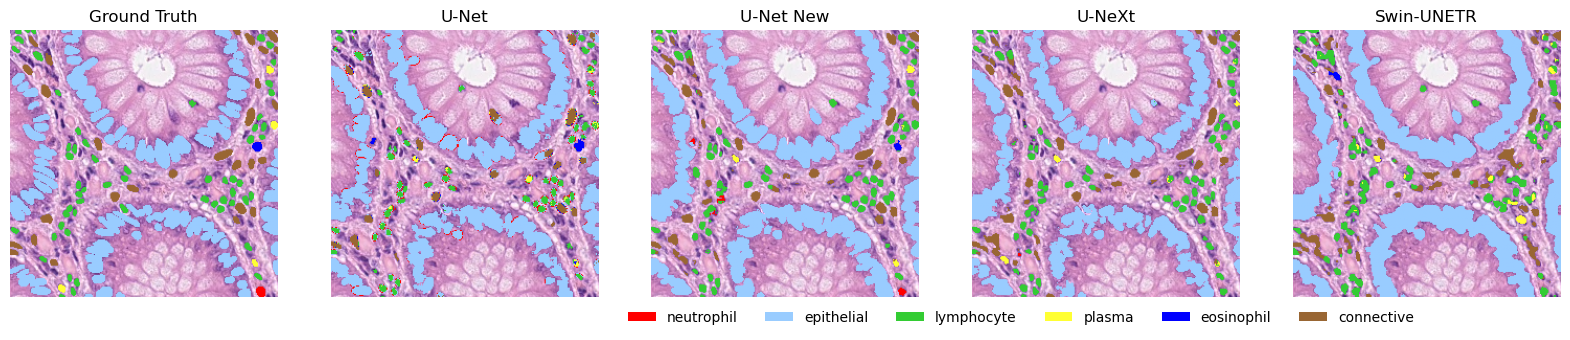

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tifffile import imread

CD = os.path.dirname(os.path.abspath("temp.ipynb"))
patch_names = pd.read_csv(os.path.join(os.path.dirname(CD), "CRC-HnE-Segmentation-Training", "histology_segmentation_training", "data", "patches", "patch_info.csv"))

img_path = os.path.join(os.path.dirname(CD), "CRC-HnE-Segmentation-Training", "histology_segmentation_training", "data","OME-TIFFs", patch_names.iloc[605, 0] + ".ome.tif")

img = np.array(imread(img_path)[:3, :, :]).transpose(1, 2, 0)
gt = np.array(imread(img_path)[3, :, :])
mask_unet_old = np.load("mask_unet_old.npy")
mask_unet_new = np.load("mask_unet_new.npy")
mask_unext = np.load("mask_unext.npy")
mask_swin = np.load("mask_swinunetr.npy")


def overlay_multiclass_mask(image, mask, class_colors):
    img_copy = image.copy()
    
    if img_copy.ndim == 2:
        img_copy = np.stack([img_copy]*3, axis=-1)

    if img_copy.max() > 1:
        img_copy = img_copy / 255.0
    
    overlay = img_copy.copy()
    mask_2d = np.squeeze(mask)
    
    for cls, color in class_colors.items():
        if cls == 0:
            continue
        bool_mask = mask_2d==cls
        overlay[bool_mask] = color
        #overlay[bool_mask, 0] = color[0]
        #overlay[bool_mask, 1] = color[1]
        #overlay[bool_mask, 2] = color[2]
    
    return overlay

masks = [gt, mask_unet_old, mask_unet_new, mask_unext, mask_swin]
titles = ["Ground Truth", "U-Net", "U-Net New", "U-NeXt", "Swin-UNETR"]

class_names = {
    0: "background",
    1: "neutrophil",
    2: "epithelial",
    3: "lymphocyte",
    4: "plasma",
    5: "eosinophil",
    6: "connective"
}

class_colors = {
    0: (0,0,0),
    1: (1.0, 0.0, 0.0),    # red
    2: (0.6, 0.8, 1.0),    # light blue
    3: (0.2, 0.8, 0.2),    # green
    4: (1.0, 1.0, 0.2),    # yellow
    5: (0.0, 0.0, 1.0),    # blue
    6: (0.6, 0.4, 0.2)     # brown
}

legend_handles = [Patch(facecolor=class_colors[i], label=class_names[i]) 
                  for i in class_colors if i != 0]

plt.figure(figsize=(20,5))

for i, mask in enumerate(masks):
    plt.subplot(1,5,i+1)
    overlay = overlay_multiclass_mask(img, mask, class_colors)
    plt.imshow(overlay)
    plt.axis('off')
    plt.title(titles[i])

plt.legend(handles=legend_handles, loc='lower right', 
           bbox_to_anchor=(0.5, -0.15), ncol=len(legend_handles), frameon=False)

plt.tight_layout()
plt.show()

In [60]:
test = np.load("../CRC-HnE-Segmentation-Training/test_ids.npy", allow_pickle=True)
if (test == test_id).all():
    print("Test IDs match the expected test set.")

Test IDs match the expected test set.


In [21]:
import torch

ckpt = torch.load("best_UneXt_lr-0.007_wd-1e-05_dropout-0.01_epoch-250_batchS-32-v1.ckpt", map_location=torch.device('cpu'))
print(ckpt.keys())

for key in ckpt.keys():
    if not key == 'optimizer_states' and not key == 'state_dict':
        print(key, ckpt[key])

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters'])
epoch 137
global_step 15042
pytorch-lightning_version 2.6.0
loops {'fit_loop': {'state_dict': {}, 'epoch_loop.state_dict': {'_batches_that_stepped': 15042}, 'epoch_loop.batch_progress': {'total': {'ready': 15042, 'completed': 15042, 'started': 15042, 'processed': 15042}, 'current': {'ready': 109, 'completed': 109, 'started': 109, 'processed': 109}, 'is_last_batch': True}, 'epoch_loop.scheduler_progress': {'total': {'ready': 137, 'completed': 137}, 'current': {'ready': 0, 'completed': 0}}, 'epoch_loop.automatic_optimization.state_dict': {}, 'epoch_loop.automatic_optimization.optim_progress': {'optimizer': {'step': {'total': {'ready': 15042, 'completed': 15042}, 'current': {'ready': 109, 'completed': 109}}, 'zero_grad': {'total': {'ready': 15042, 'completed': 15042, 'started': 15042}, 'current': {'ready': 109, 'compl

In [22]:
import torch

ckpt = torch.load("../CRC-HnE-Segmentation-Training/mlruns/unet_fromC32_Aug_backgound0_5/best_Unet_lr-0.003_wd-1e-05_dropout-0.015_epoch-250_batchS-64-v3.ckpt", map_location=torch.device('cpu'))
print(ckpt.keys())

for key in ckpt.keys():
    if not key == 'optimizer_states' and not key == 'state_dict':
        print(key, ckpt[key])

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters'])
epoch 242
global_step 13365
pytorch-lightning_version 2.6.0
loops {'fit_loop': {'state_dict': {}, 'epoch_loop.state_dict': {'_batches_that_stepped': 13365}, 'epoch_loop.batch_progress': {'total': {'ready': 13365, 'completed': 13365, 'started': 13365, 'processed': 13365}, 'current': {'ready': 55, 'completed': 55, 'started': 55, 'processed': 55}, 'is_last_batch': True}, 'epoch_loop.scheduler_progress': {'total': {'ready': 242, 'completed': 242}, 'current': {'ready': 0, 'completed': 0}}, 'epoch_loop.automatic_optimization.state_dict': {}, 'epoch_loop.automatic_optimization.optim_progress': {'optimizer': {'step': {'total': {'ready': 13365, 'completed': 13365}, 'current': {'ready': 55, 'completed': 55}}, 'zero_grad': {'total': {'ready': 13365, 'completed': 13365, 'started': 13365}, 'current': {'ready': 55, 'completed': 